# Kirkendall: A PFC application

In this application, Ref. [1] is reproduced.

[1]: ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.

## Free Energy

The free energy functional of the Kirkendall model reads:

\begin{align}
F = \int d\mathbf{x}\left[\frac{n}{2}\Lambda^0n - \frac{t}{3}n^3 + \frac{v}{4}n^4 + \gamma\psi + \frac{\omega}{2}\psi^2 + \frac{\mu}{4}\psi^4 + \frac{K}{2}\lvert\vec{\nabla\psi}\rvert^2\right]
\end{align}

where

\begin{align}
\Lambda^0 = \left(B_0^l-B_0^x\right) + B_2^l\psi^2 + B_0^x\left(1+\nabla^2\right)^2
\end{align}

### One Mode Expansion in 2D

On page 164 of *Nikolas Provatas & Ken Elder. Phase-Field Methods in Materials Science and Engineering. (Wiley-VCH Verlag GmbH & Co. KGaA, 2010). doi:10.1002/9783527631520.*, the approximated density in 2D case reads:

\begin{align}
n = \bar{n} + A\left[\frac{1}{2}cos\left(\frac{4\pi}{\sqrt{3}a}y\right)+ cos\left(\frac{2\pi}{a}x\right)cos\left(\frac{2\pi}{\sqrt{3}a}y\right)\right]
\end{align}

Not surprisingly, the density is with triangular symmetry.

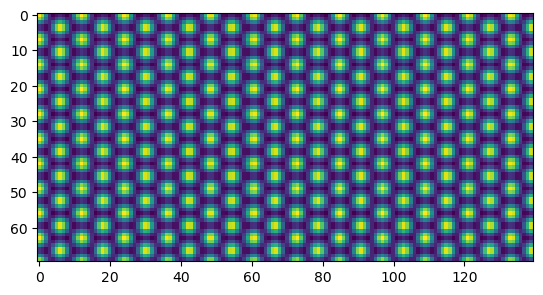

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
C = 0.5
a = 2*np.pi
# q = 2*np.pi / a * np.sqrt(3) / 2
dx = a /7.0
Lx = 10*a
Ly = 20*a
Nx = int(Lx/dx)
Ny = int(Ly/dx)
xlst = np.arange(Nx)*dx
ylst = np.arange(Ny)*dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
n = C*(0.5*np.cos(4*np.pi/(np.sqrt(3)*a)*ymat) + np.cos(2*np.pi/(a)*xmat)*np.cos(2*np.pi/(np.sqrt(3)*a)*ymat))
plt.imshow(n)

### Free Energy per Area

The free energy per area can be computed by substituting the "one-mode-expansion" density to the free energy functional, and average per area.

The period along $\vec{x}$ is $\frac{2\pi}{q}=\frac{2\pi\cdot 2a}{2\pi\sqrt{3}}=\frac{2a}{\sqrt{3}}$, along $\vec{y}$ is $\frac{2\pi}{q/\sqrt{3}}=\frac{2\pi\cdot 2a}{2\pi \cdot 3}=\frac{2a}{3}$, the unit area is $\frac{4a^2}{3\sqrt{3}}$. Substitute the one mode expansion to the free energy functional, integrate over $\{x,0,\frac{2a}{\sqrt{3}}\}, \{y,0,\frac{2a}{3}\}$ and devided by $\frac{4a^2}{3\sqrt{3}}$ to get the free energy density of the triangular phase:

## Implementation 

### Laplacian Operator 

In [1]'s dynamical Eqn. (3~4), there are Laplacian operations again and again, in order to simplify the code and to increase the accuracy of the Laplacian operator, the `scipy.ndimage.laplace` function in the scipy package is used.

The following code is used to compare our function in the [PFC: Grain Boundary Evolution](./pfc-gb.ipynb) section, and in this section:

In [ ]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
def laplacian(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)
def lap(phi, dx):
    v = ndimage.laplace(phi)/(dx**2)
    return(v)

img = plt.imread('../images/Laplace-Pierre-Simon.jpg')
img_gray = img.mean(axis=2)
edge1 = laplacian(img_gray, 0.1)
edge2 = lap(img_gray, 0.1)
fig = plt.figure()
ax1 = fig.add_subplot(121)  # left side
ax2 = fig.add_subplot(122)  # right side
ax1.imshow(edge1)
ax2.imshow(edge2)

## the Kirkendall Dynamics

In Ref. [1]'s Eq. (3~4):

\begin{align}
\frac{\partial n_A}{\partial t} &= M_A\nabla^2\left\{\Lambda^0n-tn^2+vn^3+\left[w+B_2^ln^2\right]\psi+u\psi^3-K\nabla^2\psi\right\} \\
\frac{\partial n_B}{\partial t} &= M_B\nabla^2\left\{\Lambda^0n-tn^2+vn^3-\left[w+B_2^ln^2\right]\psi-u\psi^3+K\nabla^2\psi\right\} 
\end{align}

since $n=n_A+n_B$ and $\psi=n_A-n_B$:

\begin{align}
\frac{\partial n}{\partial t} &= (M_A+M_B)\nabla^2\left(\Lambda^0n-tn^2+vn^3\right) \nonumber  \\
&+ (M_A-M_B)\left[\left(w+B_2^ln^2\right)\psi+u\psi^3-K\nabla^2\psi\right] \\
\frac{\partial \psi}{\partial t} &= (M_A-M_B)\nabla^2\left(\Lambda^0n-tn^2+vn^3\right) \nonumber  \\
&+ (M_A+M_B)\left[\left(w+B_2^ln^2\right)\psi+u\psi^3-K\nabla^2\psi\right]
\end{align}

And the parameters are

\begin{align}
a & = a = 6.927 \nonumber \\
B_0^l &= B0l = 0.7 \nonumber \\
B_2^l &= B2l = -1.8 \nonumber \\
B_0^x &= B0x = 1.0 \nonumber \\
t &= t = 0.6 \nonumber \\
v &= v = 1.0 \nonumber \\
K &= K = 4.0 \nonumber \\
w &= w = 1.0 \nonumber \\
u &= u = 4.0 \nonumber \\
n_{liquid} &= nliq = -0.2517 \nonumber \\
n_{solid} &= nsld = -0.1503 \nonumber \\
\Delta x &= dx = a/7 \nonumber 
\end{align}

### 3.1. *Single crystal: vacancy diffusion*
We first reproduce the Sec. 3.1, "a single crystal that contains an initial concentration inhomogeneity in the absence of grain boundaries, surfaces or other natural sources or sinks of vacancies". Here

\begin{align}
L_x & = Lx = a \nonumber \\
L_y & = Ly = 161 a_y \nonumber \\
\psi & = psi = 
\begin{cases}
0.1\; for\; y=[-L_y/2,0] \nonumber \\
-0.1\; for\; y=[0, L_y/2] \nonumber \\ 
\end{cases}
\nonumber \\
n & n = \bar{n} + C\left[cos(2q_yy)/2-cos(q_xx)cos(q_yy)\right] \nonumber \\
\bar{n} &= nbar = -0.1501 \nonumber \\
a_y &= ay = \sqrt{3}a \nonumber \\
q_x &= qx = \frac{2\pi}{a} \nonumber \\
q_y &= qy = \frac{q_x}{\sqrt{3}} \nonumber \\
M_A &= MA = 1.0 \nonumber \\
M_B &= MB = 0.1 \nonumber
\end{align}

C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:11: RuntimeWarning: overflow encountered in square
  ter2 = B2l*psi**2
C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:19: RuntimeWarning: overflow encountered in multiply
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:19: RuntimeWarning: overflow encountered in power
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:19: RuntimeWarning: invalid value encountered in add
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:19: RuntimeWarning: invalid value encountered in multiply
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_3624\3839683843.py:25: RuntimeWarning: overflow encountered in square
  ter1 = (MA-MB)*lapCalc(lmdn-t*n*

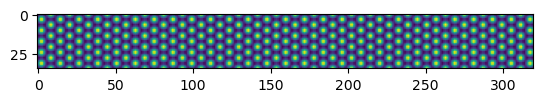

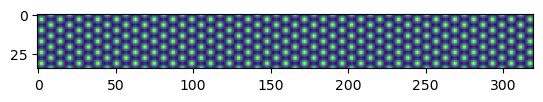

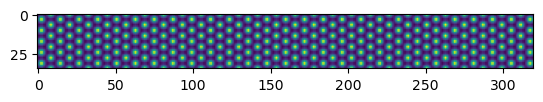

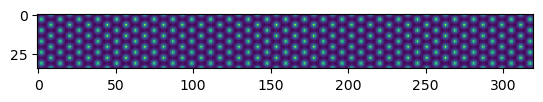

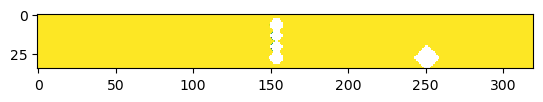

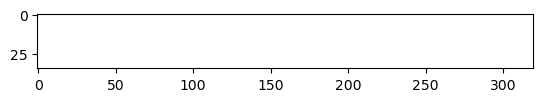

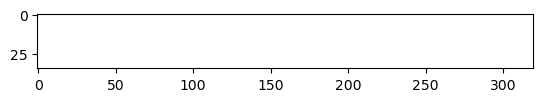

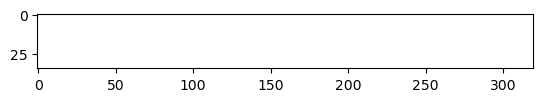

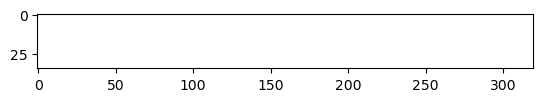

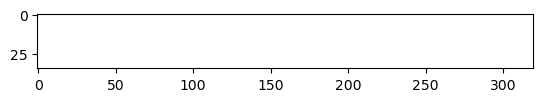

In [2]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
def lapCalc(phi, dx):
    lap = ndimage.laplace(phi)/(dx**2)
    return(lap)
def lmdnCalc(B0l, B2l, B0x, dx, psi, n):
    lapn = lapCalc(n, dx)
    lap2n = lapCalc(lapn, dx)
    ter1 = (B0l-B0x)*n
    ter2 = B2l*psi**2
    ter3 = B0x*(n+2*lapn+lap2n)
    lmdn = ter1 + ter2 + ter3
    return(lmdn)
def dynnCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n):
    lmdn = lmdnCalc(B0l, B2l, B0x, dx, psi, n)
    lappsi = lapCalc(psi, dx)
    ter1 = (MA+MB)*lapCalc(lmdn-t*n**2+v*n**3, dx)
    ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
    dynn = ter1 + ter2
    return(dynn)
def dynpsiCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n):
    lmdn = lmdnCalc(B0l, B2l, B0x, dx, psi, n)
    lappsi = lapCalc(psi, dx)
    ter1 = (MA-MB)*lapCalc(lmdn-t*n**2+v*n**3, dx)
    ter2 = (MA+MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
    dynpsi = ter1 + ter2
    return(dynpsi)
# parameter list
a = 2*np.pi
ay = np.sqrt(3)*a
# nbar = -0.1501
nbar = -0.1
B0l = 0.7
B2l = -0.8
B0x = 1.0
t = 0.6
v = 1.0
K = 4.0
w = 1.0
u = 4.0
dt = 0.00001
dx = a/7
Lx = 5*a
Ly = 161*ay
Nx = int(Lx/dx)
Ny = int(Ly/dx)
Ny_div2 = int(Ny/2)
qx = 2*np.pi / a
qy = qx / np.sqrt(3)
C = 0.7
MA = 0.05
MB = 0.05
tstep = 2000
tdump = 200
xlst = np.arange(Nx) * dx
ylst = np.arange(Ny) * dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
# Initialisation
psi = np.zeros((Nx, Ny))
psi[:,Ny_div2:] = 0.1
psi[:,:Ny_div2] = -0.1
n = nbar + C*(0.5*np.cos(4*np.pi/(np.sqrt(3)*a)*ymat) + np.cos(2*np.pi/(a)*xmat)*np.cos(2*np.pi/(np.sqrt(3)*a)*ymat))
for t in range(tstep):
    n += dt * dynnCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n)
    psi += dt * dynpsiCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n)
    if (t%tdump == 0):
        plt.figure()
        plt.imshow(n[:,Ny_div2-160:Ny_div2+160]) # 样品很长，只展示中间320个单位长度的信息